# EXERCISE 1 - Gradient descent & Deep Neural Networks

Group 2607
* Daniele Ghezzi 2195461
* Fabio Cimino ...
* Riccardo Ferrante 2196576
* Federico Scianna ... 

## 1. Random search of best hyperparameters

We want to perform random search on a simple feed-forward neural network, aiming to find the hyperparameter settings that achieve the highest accuracy on the validation set. Indeed, random search is an optimization technique that tests random combinations of hyperparameters from a predefined space, offering a highly efficient way to tune the model (since it does not evaluate all possible combinations of hyperparameters, unlike Grid Search).

First, we preprocess the data as done in class.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from keras.models import Sequential
from keras.layers import Dense, Dropout
import keras
from keras_tuner import RandomSearch
import tensorflow.random as tf_r

%run useful.py

plt.rcParams['font.size'] = 13

N=12000
L=8
B=10

TYPE=3

# we set the seeds for reproducibility
np.random.seed(12345)
tf_r.set_seed(12345)

2026-03-08 20:37:28.954167: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# preprocessing
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

perc_train = 0.7
perc_valid = 0.15
perc_test = 0.15

x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ', dtype=int)

N_train = int(perc_train * N)
N_val = int(perc_valid * N)
N_test = N - N_train - N_val
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_val}\ntest: {N_test}')

# split data into train/validation/test sets and check 
(x_train, y_train) = (x[0:N_train],y[0:N_train])
(x_val, y_val) = (x[N_train:N_train+N_val],y[N_train:N_train+N_val])
(x_test, y_test) = (x[N_train+N_val:],y[N_train+N_val:])
print("Train:",len(x_train),"\t Validation:",len(x_val),"\t Test:",len(x_test))

x_train_mean = np.mean(x_train, axis=0)
x_train_std = np.std(x_train, axis=0)
x_val_mean = np.mean(x_val, axis=0)
x_val_std = np.std(x_val, axis=0)
x_test_mean = np.mean(x_test, axis=0)
x_test_std = np.std(x_test, axis=0)
x_train = Standardize(x_train, x_train_mean, x_train_std)
x_val = Standardize(x_val, x_val_mean, x_val_std)
x_test = Standardize(x_test, x_test_mean, x_test_std)
print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

data: 12000
train: 8400
valid: 1800
test: 1800
Train: 8400 	 Validation: 1800 	 Test: 1800
after rescaling (train):
mean value= [ 9.17572896e-16  1.18834043e-14 -1.95478554e-15 -3.53337069e-15
 -6.42594443e-15 -2.40365928e-15 -2.88332932e-15 -8.27623684e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


We perform random search using the KerasTuner library. We define a build_model function that specifies the hyperparameter search space for training. While keeping the network architecture fixed, we search over activation functions, dropout rates, optimizers, and learning rates.

In [4]:
def build_model(hp):
    
    model = keras.Sequential()
    
    # we define the activation and dropout hyperparameters to tune
    hp_activation = hp.Choice('activation', values=['relu', 'tanh', 'sigmoid', 'elu'])
    hp_dropout_rate = hp.Choice('dropout_rate', values=[0.0, 0.1, 0.2])
    
    # we build the architecture (3 layers, 20 neurons each)
    model.add(keras.layers.Dense(20, activation=hp_activation, input_shape=(L,)))
    model.add(keras.layers.Dropout(rate=hp_dropout_rate))

    model.add(keras.layers.Dense(20, activation=hp_activation))
    model.add(keras.layers.Dropout(rate=hp_dropout_rate))

    model.add(keras.layers.Dense(20, activation=hp_activation))
    model.add(keras.layers.Dropout(rate=hp_dropout_rate))

    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    # we set the optimizer and learning rate hyperparameters to tune
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-1, 1e-2, 1e-3, 1e-4])
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])
    
    if hp_optimizer == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)
    elif hp_optimizer == 'rmsprop':
        optimizer = keras.optimizers.RMSprop(learning_rate=hp_learning_rate)
    else:
        optimizer = keras.optimizers.SGD(learning_rate=hp_learning_rate, nesterov=True)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

Next, we initialize the RandomSearch tuner, setting the maximum number of random combinations to test to 20 and the executions per trial to one. Admittedly, this is a lightweight configuration. Indeed, to better explore the hyperparameter space, we should evaluate more combinations and increase the executions per trial to reduce variance from random weight initialization. We also set the number of training epochs to 15, as we observed that models typically begin to overfit beyond this point.

In [ ]:
tuner = RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=20,  # maximum number of random combinations to test in random search
    executions_per_trial=1, # number of models to train
    directory='my_tuning_dir',
    project_name='random_search_demo'
)

# we execute the search (batch_size=32 by default)
tuner.search(
    x_train, 
    y_train, 
    epochs=15, # we observe that above 15 epochs the models start to overfit 
    validation_data=(x_val, y_val)
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Activation Function: {best_hps.get('activation')}")
print(f"Best Optimizer: {best_hps.get('optimizer')}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")
print(f"Best Dropout Rate: {best_hps.get('dropout_rate')}")

Trial 20 Complete [00h 00m 35s]
val_accuracy: 0.9366666674613953

Best val_accuracy So Far: 0.9366666674613953
Total elapsed time: 00h 11m 09s
Best Activation Function: elu
Best Optimizer: rmsprop
Best Learning Rate: 0.01
Best Dropout Rate: 0.0


Random Search optimizes models by testing random combinations of hyperparameters from a defined space. It is highly computationally efficient and scales well, although it cannot guarantee finding the absolute optimal configuration. Conversely, the opposite method is Grid Search, which exhaustively evaluates every possible combination. While this guarantees finding the best configuration within that specific grid, it becomes extremely computationally expensive and impractical as the number of hyperparameters increases.

# 2. Data Augmentation

We do the analyis using the best hyperpararmeters coming from the previous Random Search. 

First, we reduce data and observe the test loss and accuracy.

In [23]:
def reduce_data(x_train, y_train, fraction):
    rnd_idx = np.random.choice(len(x_train), size=int(fraction*len(x_train)), replace=False)
    return x_train[rnd_idx], y_train[rnd_idx]

activation = best_hps.get('activation')
dropout_rate = best_hps.get('dropout_rate')
learning_rate = best_hps.get('learning_rate')
optimizer = best_hps.get('optimizer')

model = Sequential()
model.add(Dense(20, activation=activation, input_shape=(L,)))
model.add(Dropout(rate=dropout_rate))
model.add(Dense(20, activation=activation))
model.add(Dropout(rate=dropout_rate))
model.add(Dense(20, activation=activation))
model.add(Dropout(rate=dropout_rate))
model.add(Dense(1, activation='sigmoid'))

if optimizer == 'adam':
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
elif optimizer == 'rmsprop':
    optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
else:
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate, nesterov=True)
    
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# we train the model on different fractions of the training data and evaluate its performance on the validation set
testloss_list = []
testacc_list = []
fraction_list = np.linspace(0.01, 1., 10)
for iter in range(len(fraction_list)):
    
    x_train_red, y_train_red = reduce_data(x_train, y_train, fraction_list[iter])
    print(f'Lenght training data: {len(x_train_red)} (fraction = {fraction_list[iter]:.2f})')
    
    if len(x_train) > 32:
        batch = 32
    else:
        batch = len(x_train)
    
    fit = model.fit(x_train_red, y_train_red,
               epochs = 15, batch_size = batch,
               validation_data=(x_val,y_val),
               verbose=0)
    
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f'Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}\n')
    testloss_list.append(test_loss)
    testacc_list.append(test_acc)

/home/dghezzi/LaboratoryOfComputationalPhysics_Y8/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Lenght training data: 84 (fraction = 0.01)
Test loss: 0.9702, Test accuracy: 0.5111

Lenght training data: 1008 (fraction = 0.12)
Test loss: 0.3150, Test accuracy: 0.8556

Lenght training data: 1932 (fraction = 0.23)
Test loss: 0.1963, Test accuracy: 0.9172

Lenght training data: 2856 (fraction = 0.34)
Test loss: 0.2601, Test accuracy: 0.9083

Lenght training data: 3780 (fraction = 0.45)
Test loss: 0.1404, Test accuracy: 0.9444

Lenght training data: 4704 (fraction = 0.56)
Test loss: 0.1473, Test accuracy: 0.9439

Lenght training data: 5628 (fraction = 0.67)
Test loss: 0.1637, Test accuracy: 0.9422

Lenght training data: 6552 (fraction = 0.78)
Test loss: 0.1314, Test accuracy: 0.9494

Lenght training data: 7476 (fraction = 0.89)
Test loss: 0.1403, Test accuracy: 0.9461

Lenght training data: 8400 (fraction = 1.00)
Test loss: 0.1295, Test accuracy: 0.9511



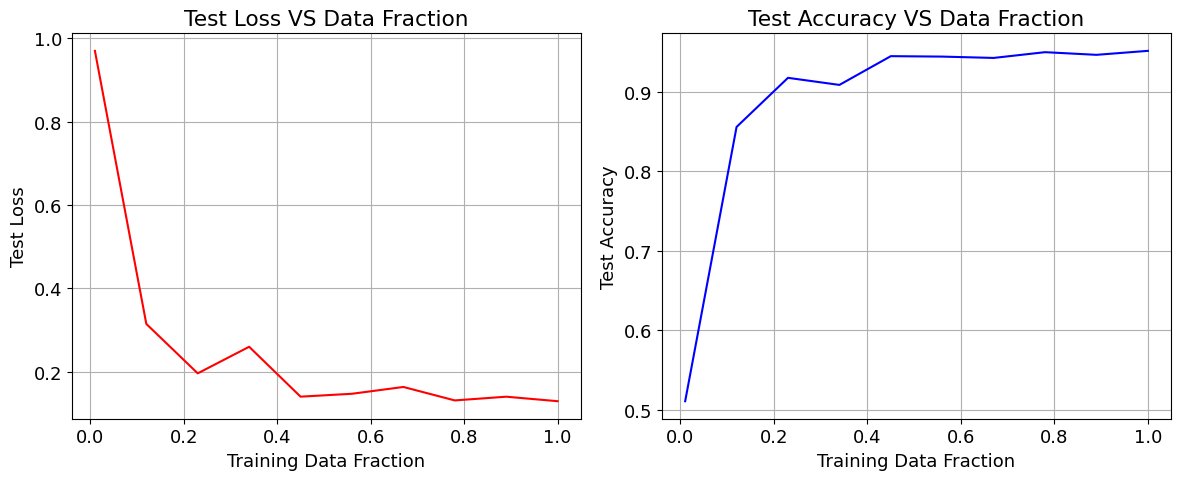

In [24]:
# plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(fraction_list, testloss_list, color='red')
ax[0].set_xlabel('Training Data Fraction')
ax[0].set_ylabel('Test Loss')
ax[0].set_title('Test Loss VS Data Fraction')
ax[0].grid()
ax[1].plot(fraction_list, testacc_list, color='blue')
ax[1].set_xlabel('Training Data Fraction')
ax[1].set_ylabel('Test Accuracy')
ax[1].set_title('Test Accuracy VS Data Fraction')
ax[1].grid()
plt.plot()
plt.tight_layout()

As expected, the loss decreases and accuracy increases as the amount of training data grows. However, beyond a certain number of samples, the accuracy begins to plateau.

Next, we explore data augmentation by introducing random Gaussian noise into the training dataset. Data augmentation is a technique that artificially expands the training set by creating modified copies of existing samples, helping the model generalize better and reducing overfitting.

In [25]:
def augment_data(X, y, fraction, noise_factor):

    rnd_idx = np.random.choice(len(x_train), size=int(fraction*len(x_train)), replace=False)
    X_augment = X[rnd_idx]
    y_augment = y[rnd_idx]
    
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=X_augment.shape)
    X_noisy = X_augment + noise
    
    X_augmented = np.concatenate((X, X_noisy), axis=0)
    y_augmented = np.concatenate((y, y_augment), axis=0)
    
    indices = np.random.permutation(len(X_augmented))
    
    return X_augmented[indices], y_augmented[indices]

In [26]:
testloss_list2 = []
testacc_list2 = []
fraction = 1. # we fix the fraction of training data to use for augmentation
noise_factor_list = np.linspace(0., 0.2, 10)
for noise_i in noise_factor_list:
    
    x_train_aug, y_train_aug = augment_data(x_train, y_train, fraction, noise_factor=noise_i)
    print(f'Noise on augmented data: {noise_i:.2f}')
    
    if len(x_train) > 32:
        batch = 32
    else:
        batch = len(x_train)
    
    fit = model.fit(x_train_aug, y_train_aug,
               epochs = 15, batch_size = batch,
               validation_data=(x_val,y_val),
               verbose=0)
    
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f'Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}\n')
    testloss_list2.append(test_loss)
    testacc_list2.append(test_acc)

Noise on augmented data: 0.00
Test loss: 0.1119, Test accuracy: 0.9594

Noise on augmented data: 0.02
Test loss: 0.1221, Test accuracy: 0.9572

Noise on augmented data: 0.04
Test loss: 0.1316, Test accuracy: 0.9517

Noise on augmented data: 0.07
Test loss: 0.1303, Test accuracy: 0.9539

Noise on augmented data: 0.09
Test loss: 0.1357, Test accuracy: 0.9572

Noise on augmented data: 0.11
Test loss: 0.1289, Test accuracy: 0.9489

Noise on augmented data: 0.13
Test loss: 0.1466, Test accuracy: 0.9478

Noise on augmented data: 0.16
Test loss: 0.1606, Test accuracy: 0.9444

Noise on augmented data: 0.18
Test loss: 0.1719, Test accuracy: 0.9433

Noise on augmented data: 0.20
Test loss: 0.1945, Test accuracy: 0.9322



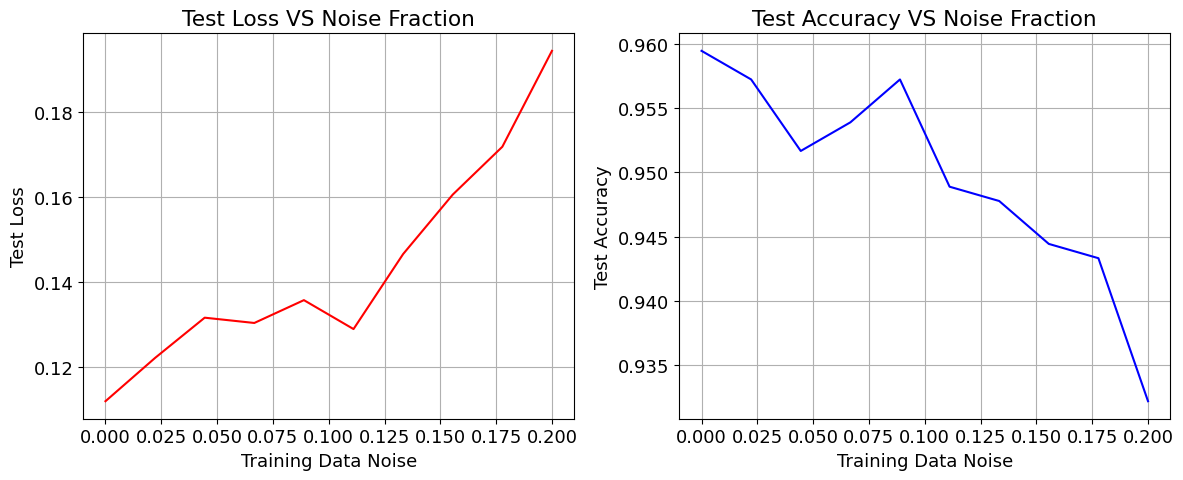

In [27]:
# plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(noise_factor_list, testloss_list2, color='red')
ax[0].set_xlabel('Training Data Noise')
ax[0].set_ylabel('Test Loss')
ax[0].set_title('Test Loss VS Noise Fraction')
ax[0].grid()
ax[1].plot(noise_factor_list, testacc_list2, color='blue')
ax[1].set_xlabel('Training Data Noise')
ax[1].set_ylabel('Test Accuracy')
ax[1].set_title('Test Accuracy VS Noise Fraction')
ax[1].grid()
plt.plot()
plt.tight_layout()

We can observe that, as noise increases, the accuracy decrease.

We can also extend the analysis by increasing the number of augmented samples. However, since we are already in the "high accuracy" plateau, we do not expect the accuracy to increase significantly.

We expect that fine-tuning both the noise fraction and the number of augmented samples could yield better accuracy.